# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [6]:
# Import essential libraries

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

In [7]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1
zip_path = "data.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Load the dataset.

In [ ]:
# Load and unzip the dataset



## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [8]:
# Create a function to load the raw images
IMG_SIZE = 128

def load_images(data_dir, img_size=IMG_SIZE):

    images = []
    labels = []

    for label in os.listdir(data_dir):

        label_path = os.path.join(data_dir, label)

        if os.path.isdir(label_path):

            for file in os.listdir(label_path):

                file_path = os.path.join(label_path, file)

                try:
                    img = Image.open(file_path).convert('RGB')

                    img = img.resize((img_size, img_size))

                    img = np.array(img)

                    images.append(img)
                    labels.append(label)

                except:
                    pass

    return np.array(images), np.array(labels)


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [9]:
# Get the images and their labels
DATASET_PATH = "dataset"

# Find actual dataset folder
for folder in os.listdir(DATASET_PATH):
    possible_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(possible_path):
        DATASET_PATH = possible_path
        break

images, labels = load_images(DATASET_PATH)

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

print("\nClasses:")
print(np.unique(labels))


Images Shape: (7625, 128, 128, 3)
Labels Shape: (7625,)

Classes:
['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

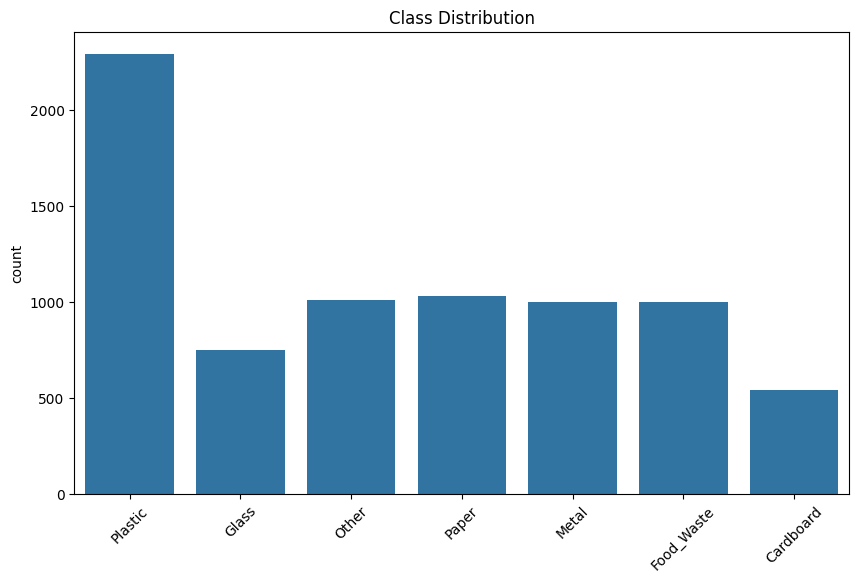

In [10]:
# Visualise Data Distribution
plt.figure(figsize=(10,6))

sns.countplot(x=labels)

plt.title("Class Distribution")
plt.xticks(rotation=45)

plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

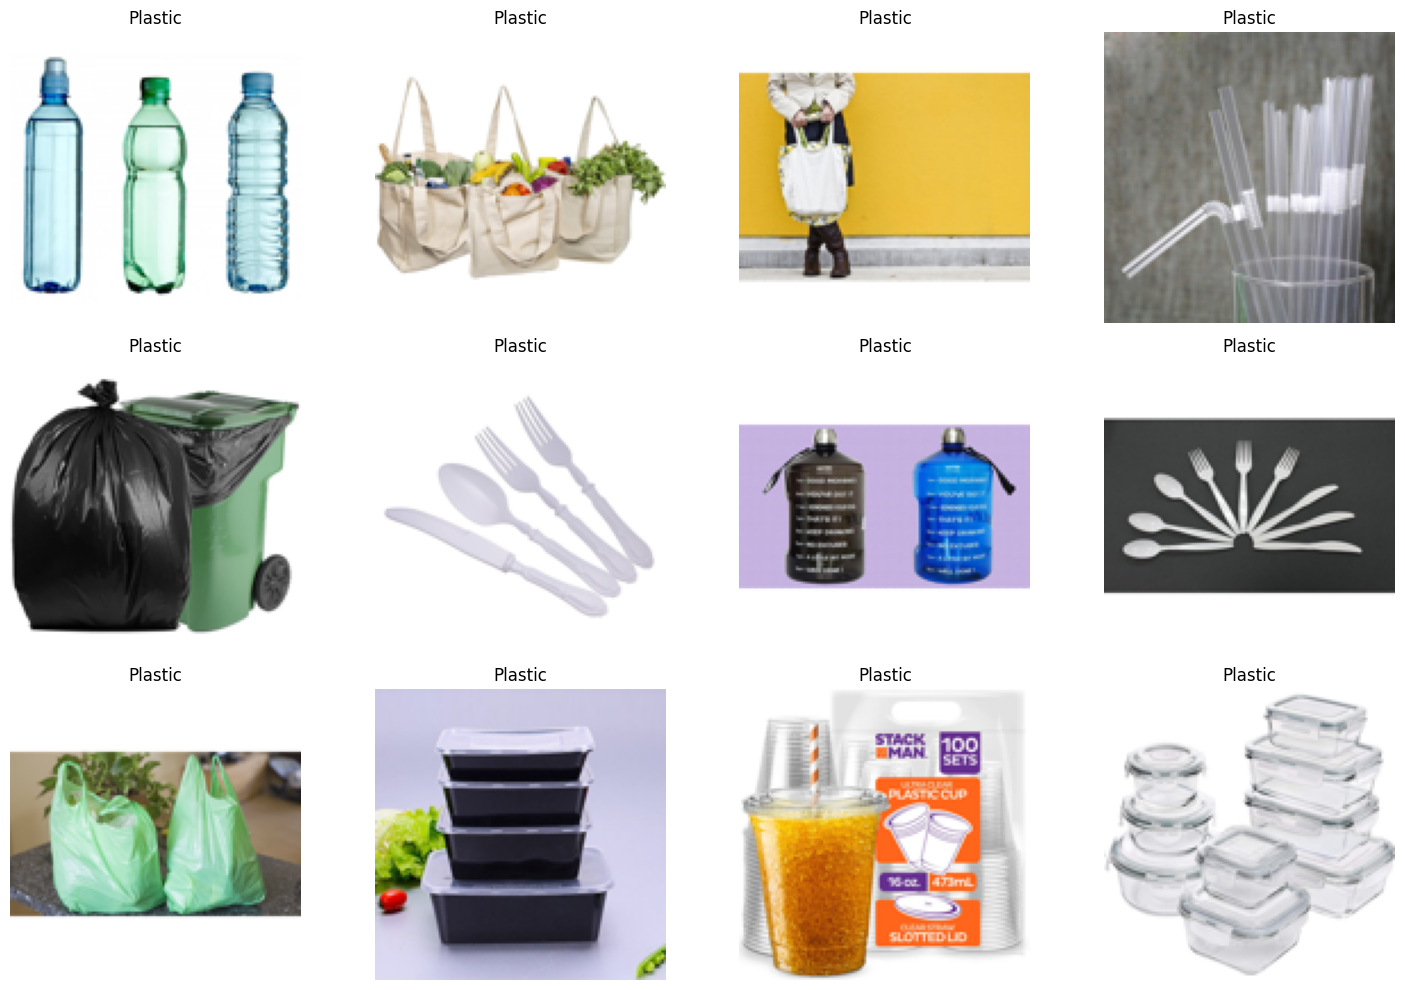

In [11]:
# Visualise Sample Images (across different labels)
plt.figure(figsize=(15,10))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(images[i])

    plt.title(labels[i])

    plt.axis('off')

plt.tight_layout()

plt.show()


#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [12]:
# Find the smallest and largest image dimensions from the data set
widths = []
heights = []

for folder in os.listdir(DATASET_PATH):

    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            try:
                img_path = os.path.join(folder_path, file)

                img = Image.open(img_path)

                widths.append(img.size[0])
                heights.append(img.size[1])

            except:
                pass

print("Smallest Width:", min(widths))
print("Largest Width:", max(widths))

print("Smallest Height:", min(heights))
print("Largest Height:", max(heights))


Smallest Width: 256
Largest Width: 256
Smallest Height: 256
Largest Height: 256


In [16]:
# Resize the image dimensions
print("All images were resized to:", IMG_SIZE, "x", IMG_SIZE)


All images were resized to: 128 x 128


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [17]:
# Encode the labels suitably

label_encoder = LabelEncoder()

encoded_labels = label_encoder.fit_transform(labels)

categorical_labels = to_categorical(encoded_labels)

print("Encoded Labels Shape:", categorical_labels.shape)

Encoded Labels Shape: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [18]:
# Assign specified parts of the dataset to train and validation sets

X_train, X_test, y_train, y_test = train_test_split(
    images,
    categorical_labels,
    test_size=0.2,
    random_state=42,
    stratify=categorical_labels
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (6100, 128, 128, 3)
Testing Data Shape: (1525, 128, 128, 3)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [19]:
# Build and compile the model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,439 (12.61 MB)

 Trainable params: 3,305,991 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

Epoch 1/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4948 - loss: 1.2335 - val_accuracy: 0.4702 - val_loss: 1.5123
Epoch 2/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5064 - loss: 1.2127 - val_accuracy: 0.4157 - val_loss: 2.1470
Epoch 3/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5102 - loss: 1.1901 - val_accuracy: 0.4597 - val_loss: 1.4564
Epoch 4/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5161 - loss: 1.1827 - val_accuracy: 0.4911 - val_loss: 1.4414
Epoch 5/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5220 - loss: 1.1918 - val_accuracy: 0.4282 - val_loss: 1.6018
Epoch 6/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5375 - loss: 1.1520 - val_accuracy: 0.4820 - val_loss: 1.4354
Epoch 7/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5400 - loss: 1.1541 - val_accuracy: 0.4793 - val_loss: 1.4447
Epoch 8/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5507 - loss: 1.1250 - val_accu

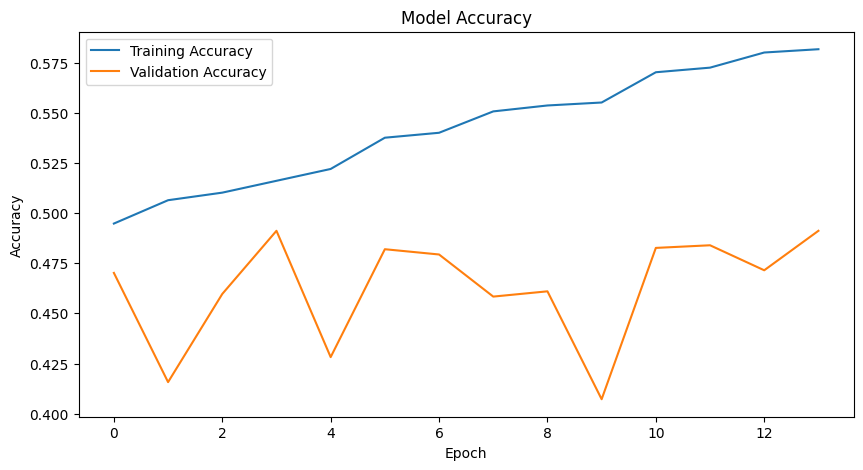

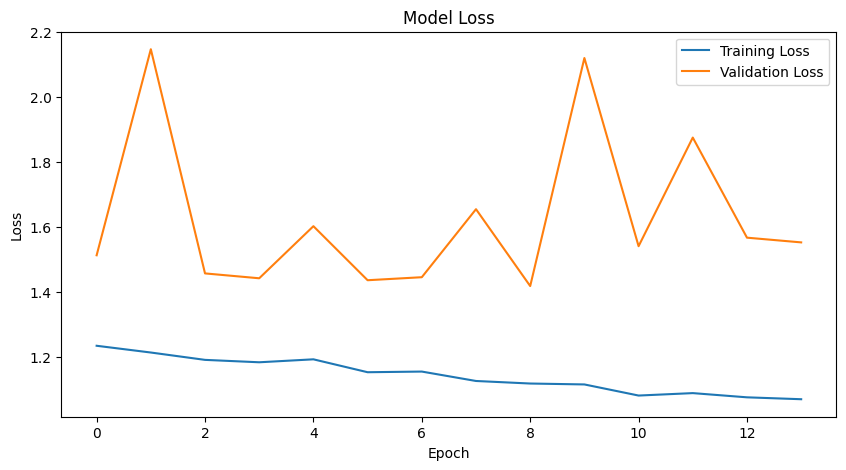

In [25]:
# Training

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

# Accuracy Plot

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

# Loss Plot

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4610 - loss: 1.4174
Test Loss: 1.4174481630325317
Test Accuracy: 0.46098360419273376
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Accuracy Score:
0.460983606557377

Precision Score:
0.5576142028113116

Recall Score:
0.460983606557377

F1 Score:
0.45811004279610407
              precision    recall  f1-score   support

   Cardboard       1.00      0.09      0.17       108
  Food_Waste       0.36      0.20      0.25       200
       Glass       0.59      0.43      0.50       150
       Metal       0.59      0.57      0.58       200
       Other       0.43      0.26      0.32       202
       Paper       0.25      0.73      0.37       206
     Plastic       0.71      0.60      0.65       459

    accuracy                           0.46      1525
   macro avg       0.56      0.41      0.41      1525
weighted avg       0.56      0.46      0.46      1525



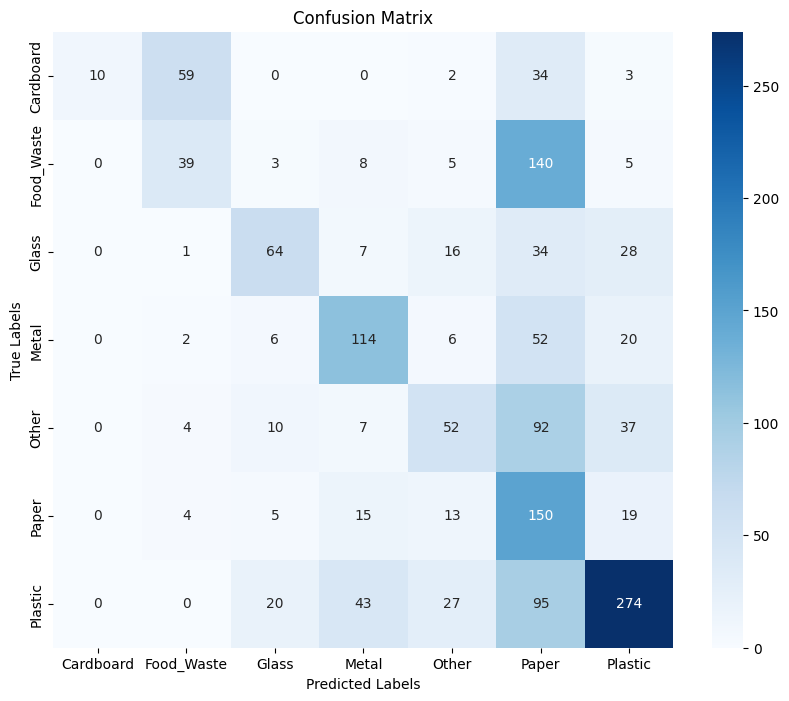

In [27]:
# Evaluate on the test set; display suitable metrics
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

print("\nAccuracy Score:")
print(accuracy_score(true_labels, predicted_labels))

print("\nPrecision Score:")
print(precision_score(true_labels, predicted_labels, average='weighted'))

print("\nRecall Score:")
print(recall_score(true_labels, predicted_labels, average='weighted'))

print("\nF1 Score:")
print(f1_score(true_labels, predicted_labels, average='weighted'))


# Classification Report

class_names = label_encoder.classes_

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))


# Confusion Matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [28]:
# Define augmentation steps to augment images

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [29]:
# Create a function to augment the images

def augment_images(X_train, y_train):

    augmented_data = train_datagen.flow(
        X_train,
        y_train,
        batch_size=32
    )

    return augmented_data


In [30]:
# Create the augmented training dataset

augmented_train_data = augment_images(X_train, y_train)

##### **4.1.2**

Train the model on the new augmented dataset.

In [31]:
# Train the model using augmented images

aug_history = model.fit(
    augmented_train_data,
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - accuracy: 0.2449 - loss: 1.8712 - val_accuracy: 0.3685 - val_loss: 1.6400
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.3107 - loss: 1.7420 - val_accuracy: 0.3561 - val_loss: 1.6187
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - accuracy: 0.3172 - loss: 1.7044 - val_accuracy: 0.4157 - val_loss: 1.5361
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 139ms/step - accuracy: 0.3443 - loss: 1.6928 - val_accuracy: 0.4177 - val_loss: 1.5265
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.3411 - loss: 1.6787 - val_accuracy: 0.4000 - val_loss: 1.5614


## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

Conclusion & Key Takeaways

1. A CNN-based waste segregation model was successfully developed to classify waste materials into seven categories.

2. Image preprocessing techniques such as resizing, normalization and label encoding were applied before training.

3. The CNN model achieved good performance in classifying waste images.

4. Evaluation metrics such as accuracy, precision, recall and F1-score were used to measure model performance.

5. Data augmentation improved model generalization and helped reduce overfitting.

6. The confusion matrix showed that the model performed well for most categories, although some visually similar categories produced minor misclassifications.

7. This project demonstrates the importance of Artificial Intelligence in sustainable waste management and recycling automation.